# Phase 1 Dataset Analysis

This notebook analyzes `data/master_dataset.csv` to assess dataset quality, structure, and modeling implications for the bug → testcase recommendation system.

In [2]:
pip install pandas numpy matplotlib seaborn jupyter notebook scikit-learn python-dotenv requests beautifulsoup4 tqdm

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using 

Could not find platform independent libraries <prefix>


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Karthik Maiya/Desktop/testcasepred/data/master_dataset.csv")

print(df.shape)
df.head()

(5187, 10)


,bug_id,bug_title,bug_description,bug_tags,priority,severity,testcase_id,testcase_title,testcase_description,test_steps
0,168681,Simple KEM WF template not available for CTT role,NaN,NaN,NaN,4 - Low,56744,51530: ECO WF | Simple KEM Workflow,Required Roles for the test case: PDM-Author o...,1. Requester: global navigation command Folder...
1,168681,Simple KEM WF template not available for CTT role,NaN,NaN,NaN,4 - Low,476830,51530: ECO WF | Simple KEM Workflow,Required Roles for the test case: PDM-Author o...,1. Requester: global navigation command Folder...
2,61788,Testcase 61140: Editor of Configuration Context,NaN,Team 2,2.0,3 - Medium,61140,Create Configurator Context & Create Feasibili...,NaN,1. Click on New primary toolbar 2. Click on Ad...
3,61793,Testcase 61140: Editor for Configurator Contex...,NaN,Team 2,1.0,3 - Medium,61140,Create Configurator Context & Create Feasibili...,NaN,1. Click on New primary toolbar 2. Click on Ad...
4,175899,While initiate CAD_Start_Part_Release Worfklow...,NaN,Team 3,NaN,3 - Medium,62054,46846: WF | Workflow for CAD start parts release,Required Roles for the test case: Std Part Admin,1. Requester: global navigation command Folder...


## 1. Dataset Overview

We start by checking the dataset size and the number of unique bugs and test cases represented in the mapping table.

In [7]:
print("Rows:", len(df))

print("Unique Bugs:",
      df["bug_id"].nunique())

print("Unique Testcases:",
      df["testcase_id"].nunique())

Rows: 5187
Unique Bugs: 3828
Unique Testcases: 1738


In [8]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(missing)

bug_description         74.127627
priority                61.711972
testcase_description    12.184307
bug_tags                 5.513784
severity                 4.087141
bug_title                1.176017
test_steps               1.156738
bug_id                   0.000000
testcase_title           0.000000
testcase_id              0.000000
dtype: float64


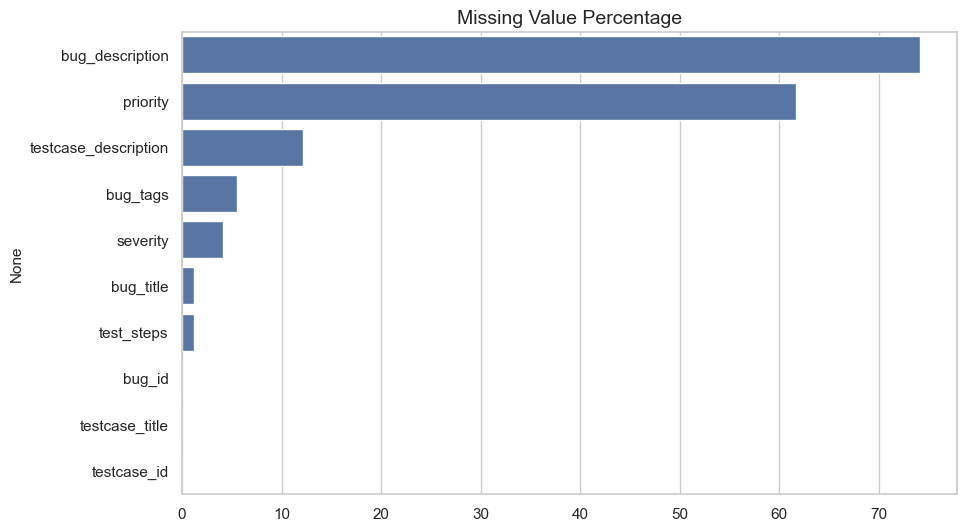

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Value Percentage")
plt.show()

In [10]:
testcases_per_bug = (
    df.groupby("bug_id")
      ["testcase_id"]
      .nunique()
)

bugs_per_testcase = (
    df.groupby("testcase_id")
      ["bug_id"]
      .nunique()
)

print("Testcases per bug")
print(testcases_per_bug.describe())

print()

print("Bugs per testcase")
print(bugs_per_testcase.describe())

Testcases per bug
count    3828.000000
mean        1.355016
std         1.393041
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        63.000000
Name: testcase_id, dtype: float64

Bugs per testcase
count    1738.000000
mean        2.984465
std         3.262334
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        32.000000
Name: bug_id, dtype: float64


In [11]:
top_testcases = (
    df["testcase_id"]
    .value_counts()
    .head(10)
)

print(top_testcases)

testcase_id
192290    32
229738    29
252114    28
188495    26
254548    21
197911    21
204223    20
217266    20
296485    20
198149    19
Name: count, dtype: int64


In [12]:
df["bug_title_len"] = (
    df["bug_title"]
      .fillna("")
      .str.len()
)

df["testcase_title_len"] = (
    df["testcase_title"]
      .fillna("")
      .str.len()
)

print(
    df[
        [
            "bug_title_len",
            "testcase_title_len"
        ]
    ].describe()
)

       bug_title_len  testcase_title_len
count    5187.000000         5187.000000
mean       65.641604           75.159437
std        28.786690           28.914855
min         0.000000            4.000000
25%        47.000000           54.000000
50%        62.000000           73.000000
75%        80.000000           95.000000
max       211.000000          189.000000


In [13]:
print(
    "Duplicate bug titles:",
    df["bug_title"].duplicated().sum()
)

print(
    "Duplicate testcase titles:",
    df["testcase_title"].duplicated().sum()
)

Duplicate bug titles: 1480
Duplicate testcase titles: 3665


In [14]:
print(df["severity"].value_counts())

print()

print(df["priority"].value_counts())

severity
3 - Medium      1852
2 - High        1639
1 - Critical    1148
4 - Low          336
Name: count, dtype: int64

priority
1.0    778
2.0    600
3.0    412
4.0    196
Name: count, dtype: int64


In [ ]:
total_rows = len(df)
total_unique_bugs = df['bug_id'].nunique(dropna=True) if 'bug_id' in df.columns else 0
total_unique_testcases = df['testcase_id'].nunique(dropna=True) if 'testcase_id' in df.columns else 0

print(f'Total rows: {total_rows}')
print(f'Total unique bugs: {total_unique_bugs}')
print(f'Total unique testcases: {total_unique_testcases}')

df.info()

## 2. Missing Value Analysis

We compute null counts and percentages for every column, then visualize the missingness pattern as a heatmap.

In [ ]:
null_counts = df.isna().sum().sort_values(ascending=False)
null_percentages = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages.round(2),
})
missing_summary

In [ ]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='mako')
plt.title('Missing Value Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

## 3. Cardinality Analysis

We estimate how many test cases are linked to each bug and how many bugs link to each test case. This helps reveal candidate generation density and asymmetry in the mapping graph.

In [ ]:
bugs_per_testcase = df.groupby('testcase_id')['bug_id'].nunique().sort_values(ascending=False)
testcases_per_bug = df.groupby('bug_id')['testcase_id'].nunique().sort_values(ascending=False)

cardinality_summary = pd.DataFrame({
    'bugs_per_testcase': bugs_per_testcase.describe(),
    'testcases_per_bug': testcases_per_bug.describe(),
})
cardinality_summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(bugs_per_testcase, bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution: Bugs per Testcase')
axes[0].set_xlabel('Unique bugs per testcase')
axes[0].set_ylabel('Frequency')

sns.histplot(testcases_per_bug, bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution: Testcases per Bug')
axes[1].set_xlabel('Unique testcases per bug')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4. Long Tail Analysis

We inspect highly repeated test cases and sparse test cases to understand label imbalance.

In [ ]:
top_repeated_testcases = bugs_per_testcase.head(20).reset_index()
top_repeated_testcases.columns = ['testcase_id', 'bug_count']
rare_testcases = bugs_per_testcase[bugs_per_testcase == 2].reset_index()
rare_testcases.columns = ['testcase_id', 'bug_count']
single_occurrence_testcases = bugs_per_testcase[bugs_per_testcase == 1].reset_index()
single_occurrence_testcases.columns = ['testcase_id', 'bug_count']

print('Top repeated testcases:')
display(top_repeated_testcases)
print('Rare testcases (bug_count == 2):')
display(rare_testcases.head(20))
print('Single-occurrence testcases:')
display(single_occurrence_testcases.head(20))

## 5. Text Statistics

We compute text length distributions for bug titles/descriptions and testcase text fields.

In [ ]:
text_columns = [
    'bug_title',
    'bug_description',
    'testcase_title',
    'testcase_description',
    'test_steps',
]

text_stats = pd.DataFrame(index=text_columns)
for column in text_columns:
    if column in df.columns:
        series = df[column].fillna('').astype(str)
        text_stats.loc[column, 'mean_length'] = series.str.len().mean()
        text_stats.loc[column, 'median_length'] = series.str.len().median()
        text_stats.loc[column, 'p95_length'] = series.str.len().quantile(0.95)
        text_stats.loc[column, 'empty_count'] = int(series.str.strip().eq('').sum())
    else:
        text_stats.loc[column, :] = None

text_stats.round(2)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, column in zip(axes.flatten(), ['bug_title', 'bug_description', 'testcase_title', 'testcase_description']):
    if column in df.columns:
        lengths = df[column].fillna('').astype(str).str.len()
        sns.histplot(lengths, bins=50, ax=ax, color='slateblue')
        ax.set_title(f'{column} length distribution')
        ax.set_xlabel('Character length')
        ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 6. Duplicate Analysis

We inspect repeated titles to identify noisy or redundant records.

In [ ]:
duplicate_bug_titles = df['bug_title'].fillna('').astype(str).value_counts()
duplicate_bug_titles = duplicate_bug_titles[duplicate_bug_titles > 1]
duplicate_testcase_titles = df['testcase_title'].fillna('').astype(str).value_counts()
duplicate_testcase_titles = duplicate_testcase_titles[duplicate_testcase_titles > 1]

print(f'Duplicate bug titles: {len(duplicate_bug_titles)}')
display(duplicate_bug_titles.head(20).reset_index().rename(columns={'index': 'bug_title', 'bug_title': 'count'}))
print(f'Duplicate testcase titles: {len(duplicate_testcase_titles)}')
display(duplicate_testcase_titles.head(20).reset_index().rename(columns={'index': 'testcase_title', 'testcase_title': 'count'}))

## 7. Metadata Analysis

We inspect the distribution of priority, severity, and tags to understand the available structured signals.

In [ ]:
metadata_columns = ['priority', 'severity', 'bug_tags']
for column in metadata_columns:
    if column in df.columns:
        print(f'\nTop values for {column}:')
        display(df[column].fillna('Missing').astype(str).value_counts().head(20).reset_index().rename(columns={'index': column, column: 'count'}))

if 'bug_tags' in df.columns:
    tag_series = df['bug_tags'].fillna('').astype(str)
    tag_counts = tag_series.str.split(';').explode().str.strip()
    tag_counts = tag_counts[tag_counts != ''].value_counts()
    print('Top tags:')
    display(tag_counts.head(20).reset_index().rename(columns={'index': 'tag', 0: 'count'}))

## 8. Summary Report

The following summary highlights the main limitations, the strongest signals available for modeling, and the resulting modeling implications.

In [ ]:
total_rows = len(df)
bug_title_missing = int(df['bug_title'].isna().sum()) if 'bug_title' in df.columns else total_rows
testcase_title_missing = int(df['testcase_title'].isna().sum()) if 'testcase_title' in df.columns else total_rows
single_occurrence_ratio = (len(single_occurrence_testcases) / len(bugs_per_testcase)) if len(bugs_per_testcase) else math.nan

summary_lines = [
    'Biggest data limitations:',
    f'- Missing values are concentrated in some text and metadata fields, which limits full-text and hybrid ranking quality.',
    f'- The long-tail distribution is strong: {len(single_occurrence_testcases)} testcases appear only once, which makes generalization difficult.',
    f'- Duplicate titles exist for both bugs and testcases, so title-only matching is noisy.',
    '',
    'Strongest available signals:',
    '- bug_title, bug_description, testcase_title, and test_steps provide the richest semantic signal for retrieval and reranking.',
    '- priority and severity offer useful structured metadata for hybrid scoring.',
    '- Tags may help cluster related work items when normalized carefully.',
    '',
    'Modeling implications:',
    '- Use retrieval + ranking rather than direct classification because testcase labels are sparse and long-tailed.',
    '- Combine text embeddings with metadata features to improve robustness on short or sparse descriptions.',
    '- Evaluate with ranking metrics such as Recall@K and MRR, not only classification accuracy.',
]

print('\n'.join(summary_lines))